# GUPPY PIPELINE 

# Generate plots of each trial where the FP signal is cut to the timeframe of the ethovision video, and it is plotted against an ethogram of the ethovision video

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated EPM + Fiber Photometry pipeline
# Flexible to zone numbering & header differences
# ==========================================================

# ----------------------------------------------------------
# Main configuration
# ----------------------------------------------------------

main_dir = Path(".").resolve()
timepoints = ["Preinduction", "W1", "W2", "W3"]

#focus on preinduction for now to save time 
#timepoints = ["Preinduction"]
timepoints = ["Preinduction", "W3"]


# Nose-point zone substrings (FLEXIBLE MATCHING)
nosepoint_substrings = [
    "Arena / Nose-point",         # NEW
    "O1_prevC1 / Nose-point",
    "O2_prevC2 / Nose-point",
    "C1_prevO1 / Nose-point",
    "C2_prevO2 / Nose-point",
    "NeutralZone / Nose-point",
]

# Fixed colors keyed by inner substring (order doesn’t matter)
zone_colors = {
    "Arena / Nose-point": "#999999",         # grey
    "O1_prevC1 / Nose-point": "#E41A1C",     # red
    "O2_prevC2 / Nose-point": "#377EB8",     # blue
    "C1_prevO1 / Nose-point": "#4DAF4A",     # green
    "C2_prevO2 / Nose-point": "#984EA3",     # purple
    "NeutralZone / Nose-point": "#FF7F00",   # orange
}

video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Helper functions
# ==========================================================

def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423"}:
        return "NE"
    if id_clean in {"374", "429"}:
        return "WT"
    return None


def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    # Mouse ID
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    return fp_id, mouse_id


def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = None
    for p in fp_folder.glob("*.csv"):
        if fp_id.lower() in p.name.lower():
            #fp_csv = p
            fil = fp_id + '.csv'
            fp_csv = fp_folder / fil
            break
    if fp_csv is None:
        raise FileNotFoundError(f"No FP CSV found in {fp_folder}")

    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        if "time" in p.name.lower() or "timestamp" in p.name.lower():
            #ts_csv = p
            import os
            directory, filename = os.path.split(p)

            # Remove leading "._" if present
            new_filename = filename.lstrip("._") if filename.startswith("._") else filename

            # Join back together
            new_path = os.path.join(directory, new_filename)
            
            ts_csv = new_path
            break
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")

    return fp_csv, ts_csv


def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])


def _get_video_window(ts: pd.DataFrame):
    """Robust detection of video ON/OFF timestamps."""
    # Time column
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")

    # Digital channel
    scol = None
    for c in ts.columns:
        if "digital" in c.lower() or "state" in c.lower():
            scol = c
            break

    # No digital info → use full recording
    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])

    # If no transitions → full interval
    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    # Use first True and first False
    try:
        video_start = float(t[state].iloc[0])
        video_stop = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except:
        pass

    # Fallback
    return float(t.iloc[0]), float(t.iloc[-1])


def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps


def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)


def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n]

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out


def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)

    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m:
            return int(m[0])

    col0 = preview.iloc[:, 0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    if not hits.empty:
        return hits.index[0]

    raise ValueError(f"Cannot detect header row in {eth_path.name}")


def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    # Time_s
    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    if tcol:
        eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
    else:
        eth["Time_s"] = np.arange(len(eth)) / video_fps

    # Flexible matching of nose-point zone columns
    matched_cols = []
    for sub in nosepoint_substrings:
        for col in eth.columns:
            if sub in str(col):
                matched_cols.append(col)
                break

    if not matched_cols:
        raise ValueError(f"No nose-point zones found in {eth_path.name}")

    return eth[["Time_s"] + matched_cols].copy(), matched_cols


def _ethogram_segments(eth, beh_cols):
    segments = []
    for beh in beh_cols:
        mask = eth[beh] == 1
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"]
        ends = eth.loc[diff == -1, "Time_s"]

        if mask.iloc[0]:
            starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
        if mask.iloc[-1]:
            ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

        for s, e in zip(starts, ends):
            segments.append(
                {"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e),
                 "Duration_s": float(e - s)}
            )
    return pd.DataFrame(segments)


def _guess_zone_color(colname):
    for sub, color in zone_colors.items():
        if sub in colname:
            return color
    return "black"


def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )

    # LED 1 – isosbestic
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    # LED 2 – GCaMP
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    # Ethogram
    for i, beh in enumerate(beh_cols):
        color = _guess_zone_color(beh)
        subset = eth_timeline[eth_timeline["Behavior"] == beh]
        for _, row in subset.iterrows():
            axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"],
                         height=0.6, color=color)

    axes[2].set_yticks(range(len(beh_cols)))
    axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Time in zone (nose-point)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)


def _extract_led_traces(fp_trim, chan):
    iso = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)


# ==========================================================
# Main loop
# ==========================================================

fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            # Load FP
            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            # Align timestamps
            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            # Detect channel
            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
            )

            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub = f"{mouse_label}__{fp_id}__{trial_stub}"

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
            }

            # Load EthoVision
            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, video_fps)
            timeline = _ethogram_segments(eth, matched_cols) #timeline for behaviours

            # added this to store timeline to use in kernel smoothing in later code blocks
            # --- inside your main loop, after timeline is created ---
            #timeline = _ethogram_segments(eth, matched_cols)  # already there

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
                "timeline": timeline,   # <-- NEW: store timeline
                "beh_cols": matched_cols
            }


            # Plot trial
            out_png = fig_dir_raw / f"{file_stub}_zones.png"
            _plot_trial(fp_trim, timeline, matched_cols, out_png,
                        title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"✔ {eth_path.name} → {out_png.name}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")



=== Processing timepoint: Preinduction ===
✔ Raw data-EP_preinduction_BigArena-Trial     1.xlsx → ID376_NE__EPM_FP0__EP_preinduction_BigArena-Trial_____1_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     2.xlsx → ID372_NE__EPM_FP1__EP_preinduction_BigArena-Trial_____2_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     3.xlsx → ID374_WT__EPM_FP2__EP_preinduction_BigArena-Trial_____3_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     4.xlsx → ID429_WT__EPM_FP3__EP_preinduction_BigArena-Trial_____4_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     5.xlsx → ID423_NE__EPM_FP5__EP_preinduction_BigArena-Trial_____5_zones.png

=== Processing timepoint: W3 ===
✔ Raw data-EPM_W3-Trial     1.xlsx → ID376_NE__EPM_FP0__EPM_W3-Trial_____1_zones.png
✔ Raw data-EPM_W3-Trial     3.xlsx → ID372_NE__EPM_FP1__EPM_W3-Trial_____3_zones.png
✔ Raw data-EPM_W3-Trial     4.xlsx → ID374_WT__EPM_FP2__EPM_W3-Trial_____4_zones.png
✔ Raw data-EPM_W3-Trial     5.xlsx → ID429_WT__EPM_FP3__EPM_W3

In [12]:
list(fp_traces.keys())[:3]
first_key = next(iter(fp_traces))
fp_traces[first_key]


{'iso':        Time_video  G0_iso415
 0        0.020000   0.033076
 1        0.060000   0.033114
 2        0.100000   0.033101
 3        0.140000   0.033125
 4        0.180000   0.033103
 ...           ...        ...
 14992  599.699232   0.032974
 14993  599.739232   0.033018
 14994  599.779232   0.032936
 14995  599.819232   0.032882
 14996  599.859232   0.032918
 
 [14997 rows x 2 columns],
 'gcamp':        Time_video  G0_gcamp470
 0        0.000000     0.033753
 1        0.040000     0.033775
 2        0.080000     0.033609
 3        0.120000     0.033639
 4        0.160000     0.033542
 ...           ...          ...
 14993  599.719232     0.033428
 14994  599.759232     0.033444
 14995  599.799232     0.033576
 14996  599.839232     0.033434
 14997  599.879232     0.033725
 
 [14998 rows x 2 columns],
 'mouse_id': '376',
 'genotype': 'NE',
 'timeline':                                 Behavior  Start_time_s  End_time_s  Duration_s
 0          In zone 3(Arena / Nose-point)         0

In [13]:
import pandas as pd

fp_traces_df = pd.DataFrame.from_dict(fp_traces, orient="index")
fp_traces_df.head()


,iso,gcamp,mouse_id,genotype,timeline,beh_cols
Preinduction__ID376_NE__EPM_FP0__EP_preinduction_BigArena-Trial_____1,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,376,NE,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID372_NE__EPM_FP1__EP_preinduction_BigArena-Trial_____2,Time_video G0_iso415 0 0.000000...,Time_video G0_gcamp470 0 0.0200...,372,NE,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID374_WT__EPM_FP2__EP_preinduction_BigArena-Trial_____3,Time_video G0_iso415 0 0.02000...,Time_video G0_gcamp470 0 0.000...,374,WT,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID429_WT__EPM_FP3__EP_preinduction_BigArena-Trial_____4,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,429,WT,Behavior Sta...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID423_NE__EPM_FP5__EP_preinduction_BigArena-Trial_____5,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,423,NE,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."


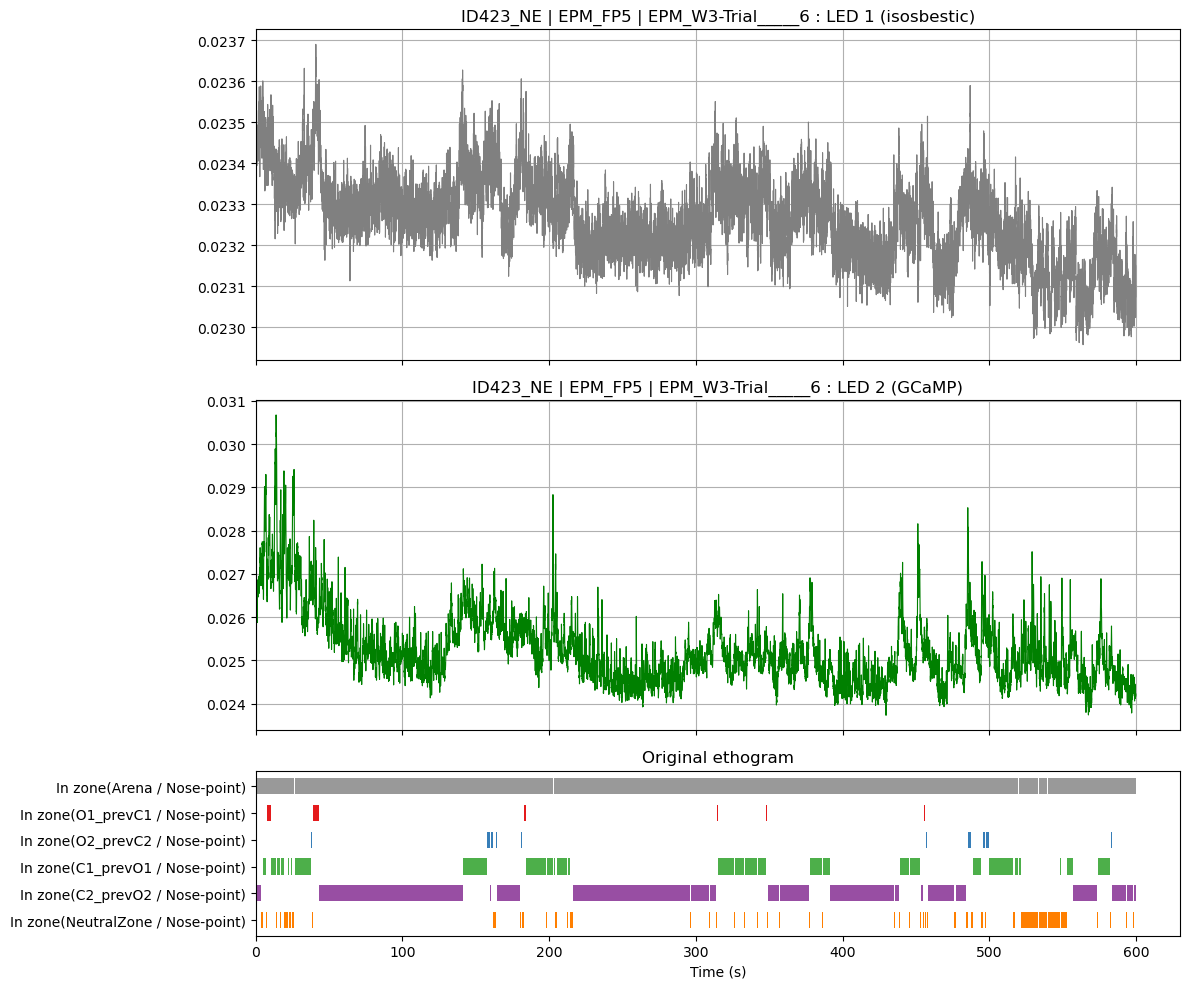

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
#beh_cols_clean = timeline_cleaned["Behavior"].unique()
#for i, beh in enumerate(beh_cols_clean):<
#    color = _guess_zone_color(beh)
#    subset = timeline_cleaned[timeline_cleaned["Behavior"] == beh]
#    for _, row in subset.iterrows():
#        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
#
#axes[3].set_yticks(range(len(beh_cols_clean)))
#axes[3].set_yticklabels(beh_cols_clean)
#axes[3].invert_yaxis()
#axes[3].set_xlabel("Time (s)")
#axes[3].set_title("Collapsed + cleaned ethogram")

plt.tight_layout()
plt.show()


In [15]:
timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter

,Behavior,Start_time_s,End_time_s,Duration_s
183,In zone(C2_prevO2 / Nose-point),0.000,3.521,3.521
268,In zone(NeutralZone / Nose-point),3.521,4.061,0.540
92,In zone(C1_prevO1 / Nose-point),4.061,4.421,0.360
269,In zone(NeutralZone / Nose-point),4.421,5.282,0.861
93,In zone(C1_prevO1 / Nose-point),5.282,7.162,1.880
...,...,...,...,...
265,In zone(C2_prevO2 / Nose-point),598.213,598.253,0.040
467,In zone(NeutralZone / Nose-point),598.253,598.694,0.441
266,In zone(C2_prevO2 / Nose-point),598.694,599.774,1.080
468,In zone(NeutralZone / Nose-point),599.774,599.934,0.160


Issues: 
- fix residual time introduced in arranged (add to last timestamp? next iteration start from previous?)

In [16]:
def smoothing_kernel(data, grainularity = 0.1, kernel_size = 5):
    """
    Smooths timeline data using a kernel.

    Args:
        data (pd.DataFrame): Timeline data.
        grainularity (float): The grainularity that the timeline data should be split up with (seconds).
        kernel_size (int): The number of 'frames' (defined by the grainularity) the kernel looks ahead 
        and behind when determining the new lable.

    Returns:
        pd.DataFrame: The timeline data reassembled with the new labels in the column 'kernel_label'.
    """
    timeline_exploded = pd.DataFrame({'timestamp' : [], 'label' : []})

    #def explode_timeline(timeline, grainularity):
    for _, row in data.iterrows():
        # timestamps = np.arange(row['Start_time_s'], row['End_time_s'], grainularity)
        timestamps = np.arange(row['Start_time_s'], row['End_time_s'] + grainularity, grainularity)

        labels = row['Behavior'] #* len(timestamps)

        timeline_exploded = pd.concat([timeline_exploded, 
                                       pd.DataFrame({'timestamp' : timestamps, 'label' : labels})])

    timeline_exploded = timeline_exploded.reset_index()

    kernel_content = []

    def most_common(lst):
        return max(set(lst), key=lst.count)

    new_labels = []

    for i, row in timeline_exploded.iterrows():
        if i < kernel_size:
            kernel_content = timeline_exploded[ : i + kernel_size]['label']

        elif i + kernel_size > len(timeline_exploded):
            kernel_content = timeline_exploded[i - (kernel_size - 1) : ]['label']

        else:
            kernel_content = timeline_exploded[i - (kernel_size - 1) : i + kernel_size]['label']
        
        new_labels.append(most_common(kernel_content.to_list()))

    timeline_exploded['kernel_label'] = new_labels

    current_label = ''

    timeline_kernel_labels = pd.DataFrame()

    # for i, row in timeline_exploded.iterrows():
    #     if current_label == row['kernel_label']:
    #         pass

    #     elif current_label == '':
    #         current_label = row['kernel_label']
    #         Start_time_s = row['timestamp']

    #     elif current_label != row['kernel_label']:
    #         timeline_kernel_labels = pd.concat([timeline_kernel_labels,
    #                                             pd.DataFrame({
    #                                                 'Behavior' : [current_label],
    #                                                 'Start_time_s' : [Start_time_s],
    #                                                 'End_time_s' : row['timestamp'],
    #                                                 'Duration_s' : row['timestamp'] - Start_time_s
    #                                             })])
    #         Start_time_s = row['timestamp']
    #         current_label = row['kernel_label']
    
    # After your existing loop that builds timeline_kernel_labels
    for i, row in timeline_exploded.iterrows():
        if current_label == row['kernel_label']:
            pass
        elif current_label == '':
            current_label = row['kernel_label']
            Start_time_s = row['timestamp']
        elif current_label != row['kernel_label']:
            timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                                pd.DataFrame({
                                                    'Behavior' : [current_label],
                                                    'Start_time_s' : [Start_time_s],
                                                    'End_time_s' : row['timestamp'],
                                                    'Duration_s' : row['timestamp'] - Start_time_s
                                                })])
            Start_time_s = row['timestamp']
            current_label = row['kernel_label']

    # --- Append the final segment ---
    if current_label != '':
        timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                            pd.DataFrame({
                                                'Behavior': [current_label],
                                                'Start_time_s': [Start_time_s],
                                                'End_time_s': [timeline_exploded['timestamp'].iloc[-1]],
                                                'Duration_s': [timeline_exploded['timestamp'].iloc[-1] - Start_time_s]
                                            })])


    return timeline_kernel_labels

timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 5)




In [17]:
timeline_kernel_labels

,Behavior,Start_time_s,End_time_s,Duration_s
0,In zone(C2_prevO2 / Nose-point),0.000,3.521,3.521
0,In zone(NeutralZone / Nose-point),3.521,4.061,0.540
0,In zone(C1_prevO1 / Nose-point),4.061,4.421,0.360
0,In zone(NeutralZone / Nose-point),4.421,5.282,0.861
0,In zone(C1_prevO1 / Nose-point),5.282,7.162,1.880
...,...,...,...,...
0,In zone(NeutralZone / Nose-point),593.492,594.072,0.580
0,In zone(C2_prevO2 / Nose-point),594.072,597.913,3.841
0,In zone(NeutralZone / Nose-point),597.913,598.694,0.781
0,In zone(C2_prevO2 / Nose-point),598.694,600.034,1.340


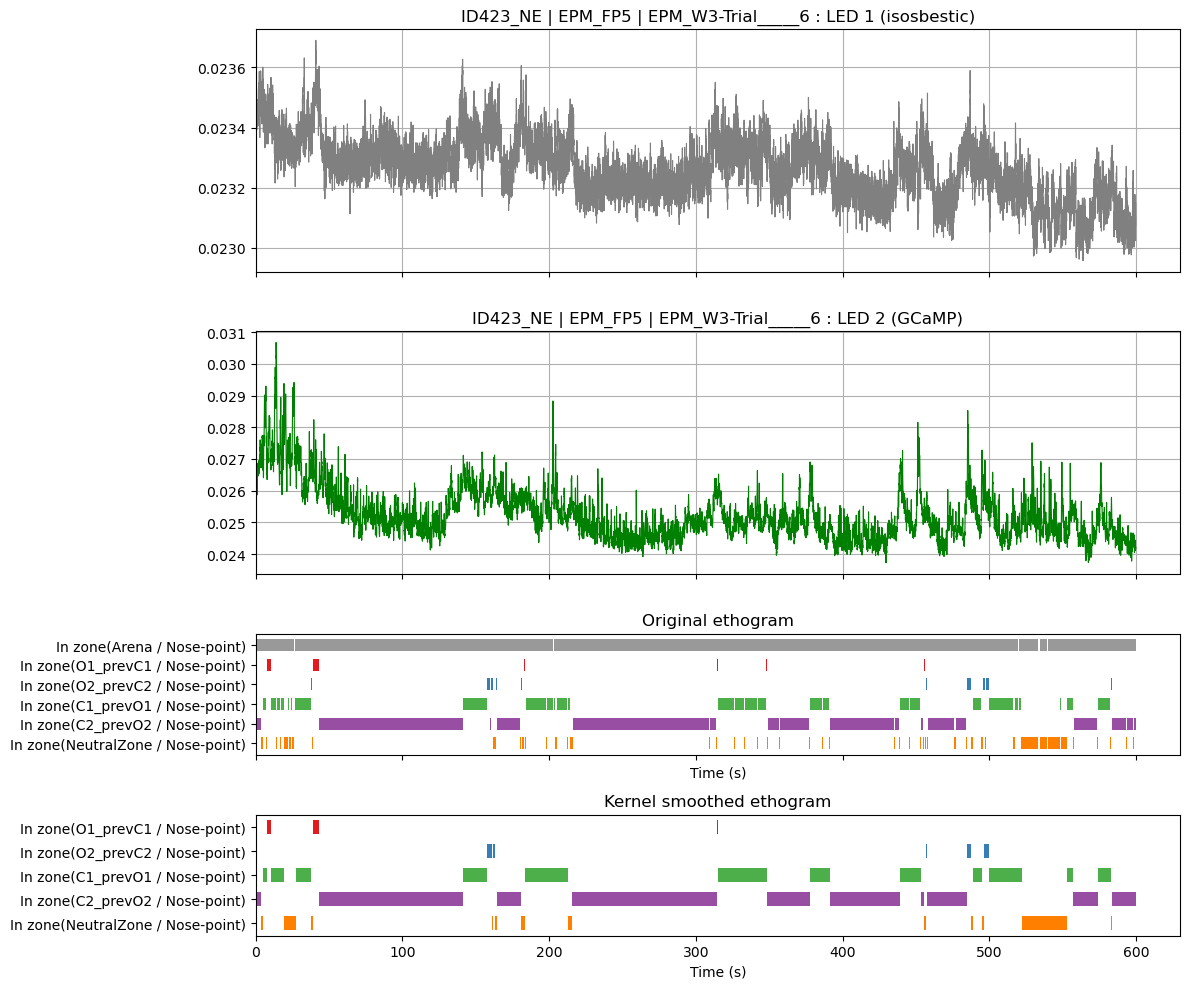

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2,1, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 20) #play around with adjusting kernel size and granularity
#beh_cols_clean = timeline_kernel_labels["Behavior"].unique()
beh_cols_clean = [ # samme rækkefølge som plottet ovenfor
'In zone(O1_prevC1 / Nose-point)',
'In zone(O2_prevC2 / Nose-point)',
'In zone(C1_prevO1 / Nose-point)',
'In zone(C2_prevO2 / Nose-point)',
'In zone(NeutralZone / Nose-point)'
]
for i, beh in enumerate(beh_cols_clean):
    color = _guess_zone_color(beh)
    subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[3].set_yticks(range(len(beh_cols_clean)))
axes[3].set_yticklabels(beh_cols_clean)
axes[3].invert_yaxis()
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Kernel smoothed ethogram")

plt.tight_layout()
plt.show()


# generate the above plot for all trials

In [19]:
#print(timeline_kernel_labels['Behavior'].unique())

print(timeline_kernel_labels['Behavior'])

0      In zone(C2_prevO2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(O1_prevC1 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(O1_prevC1 / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(O1_prevC1 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(C1_prevO1 

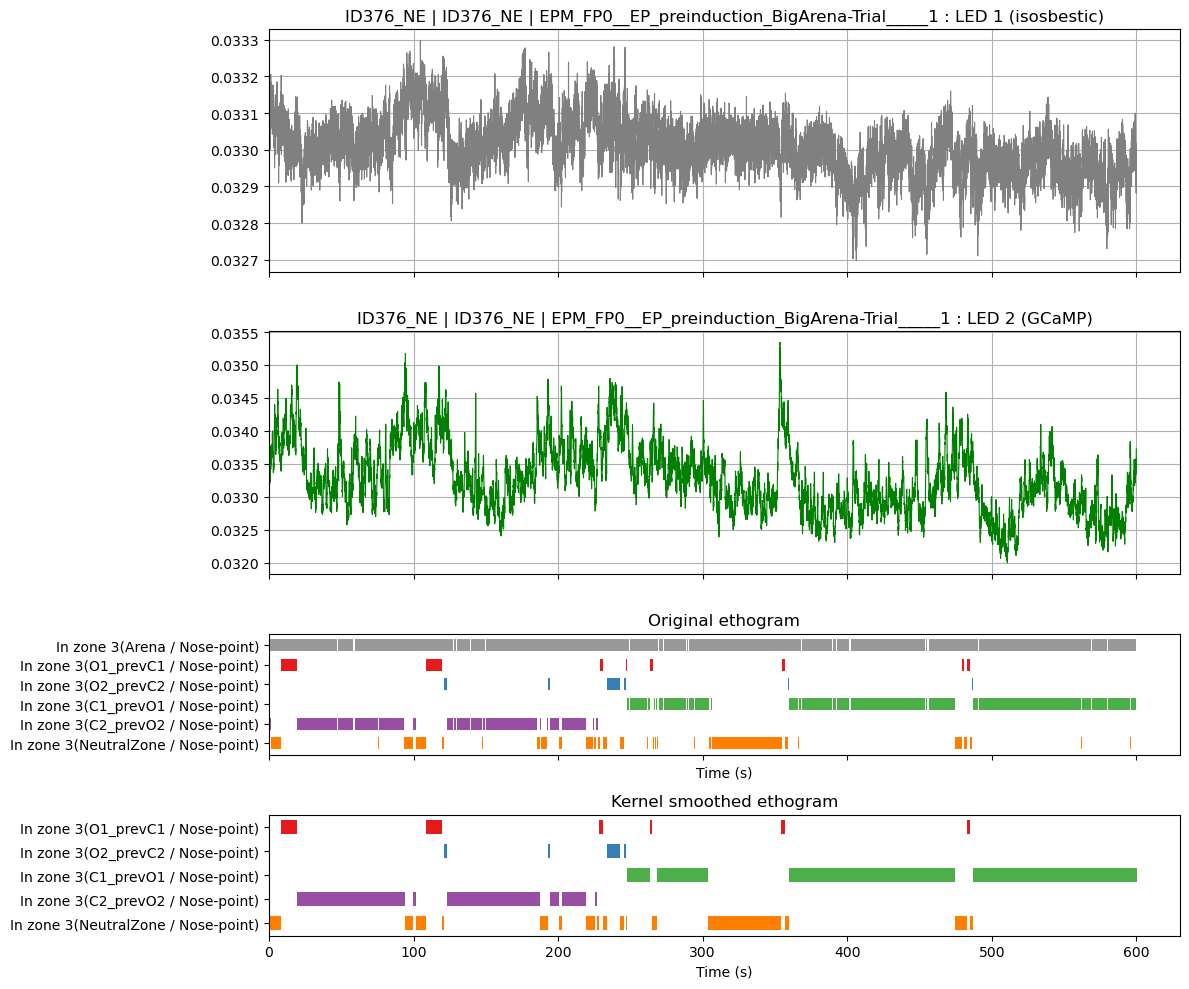

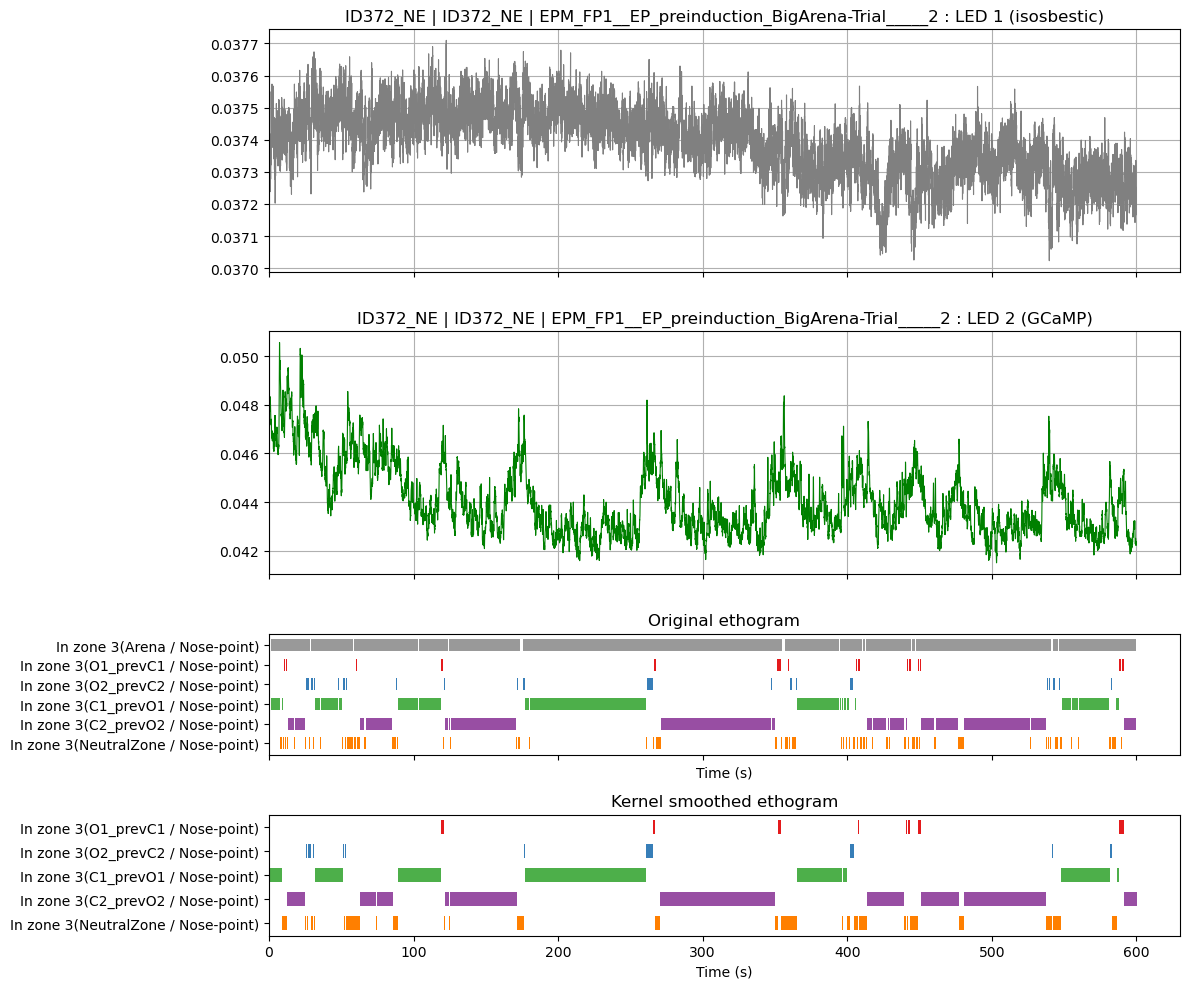

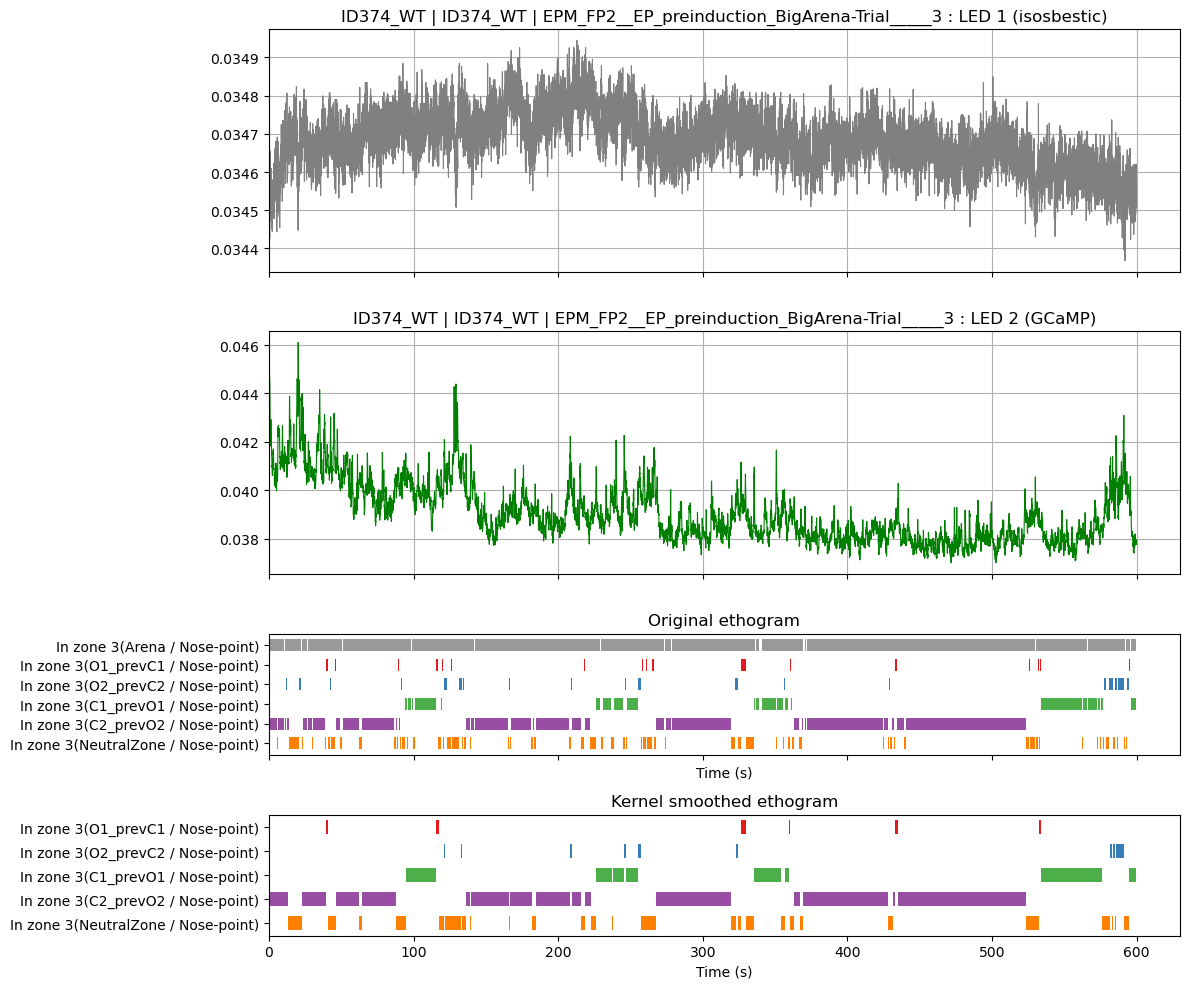

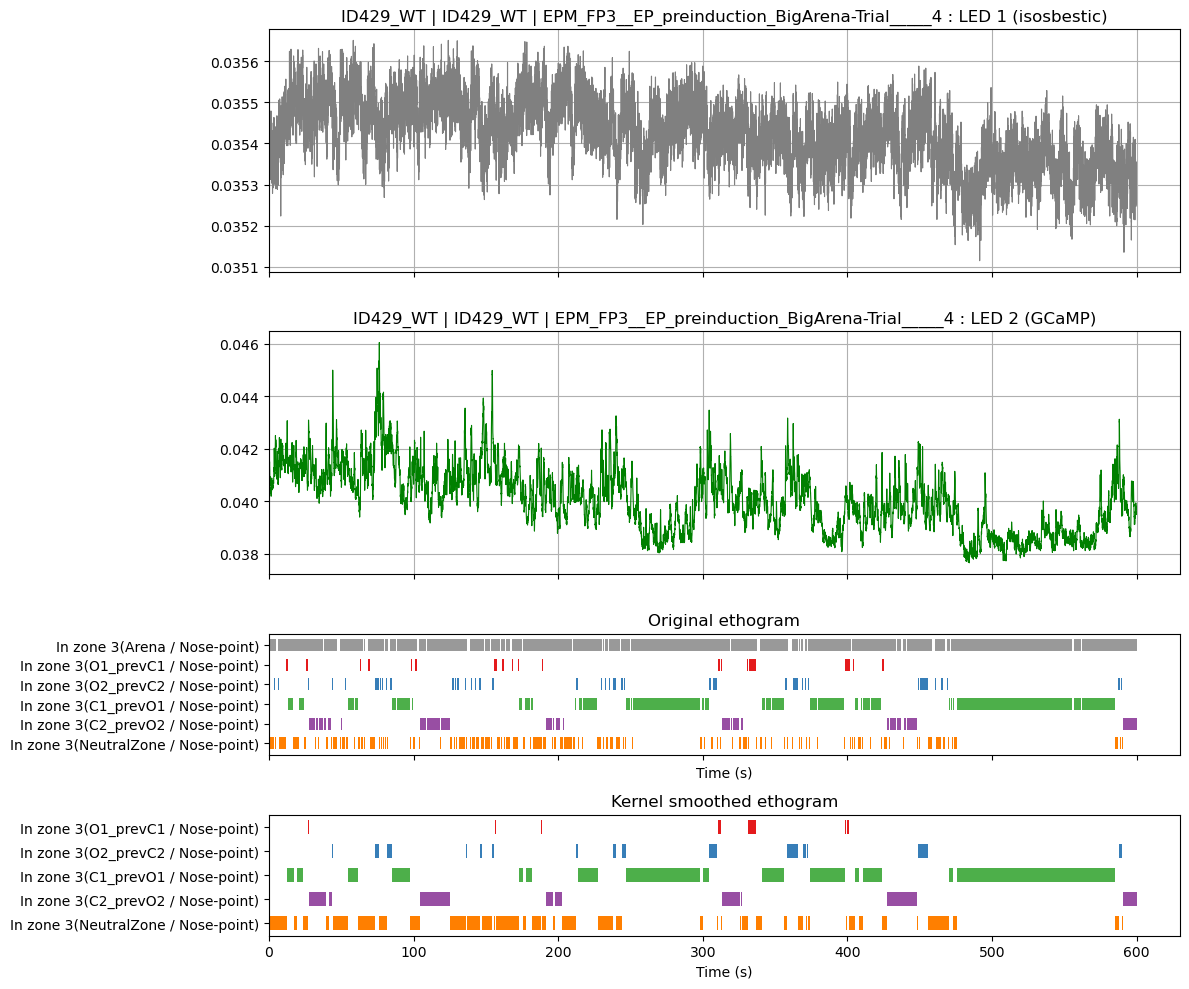

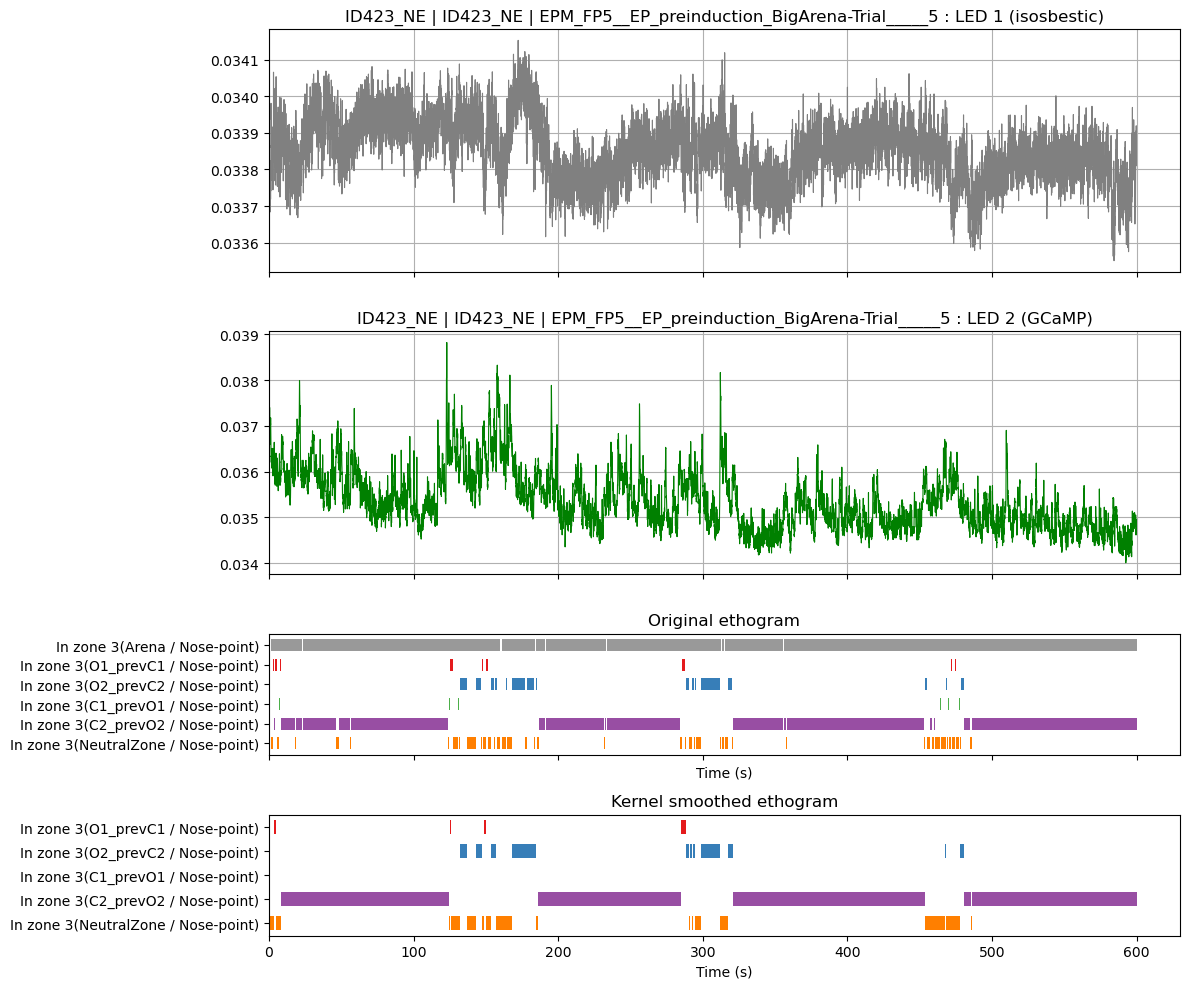

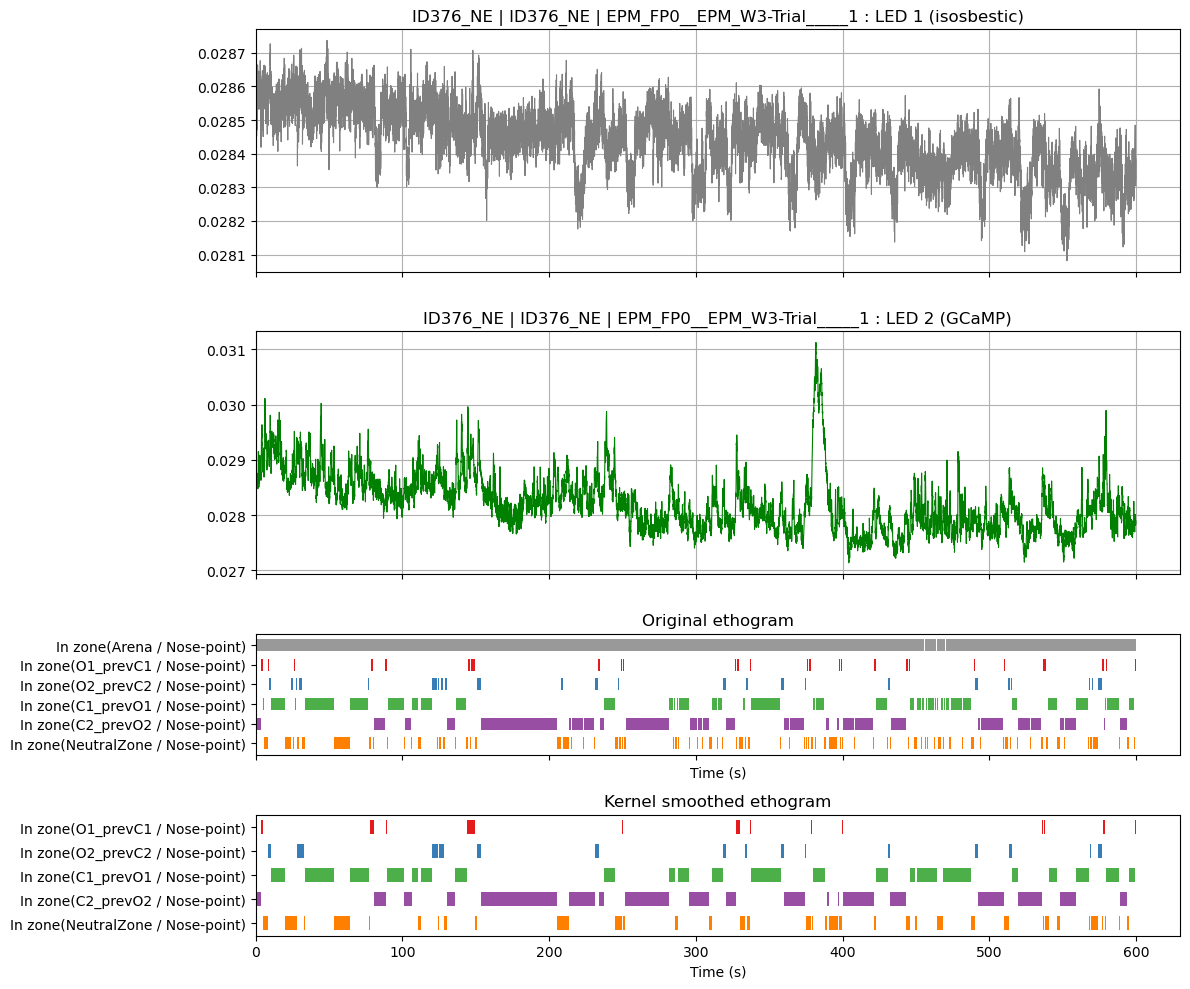

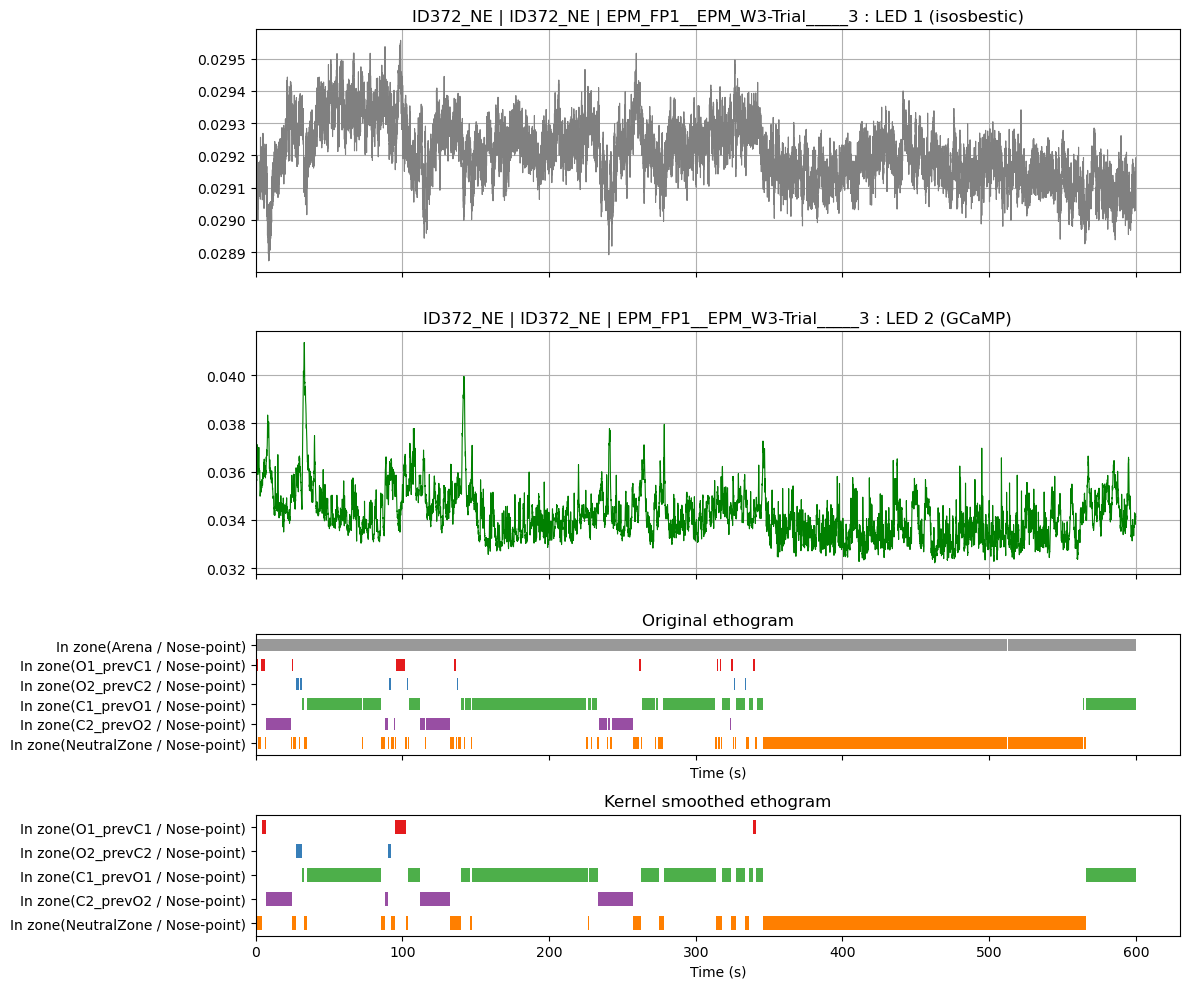

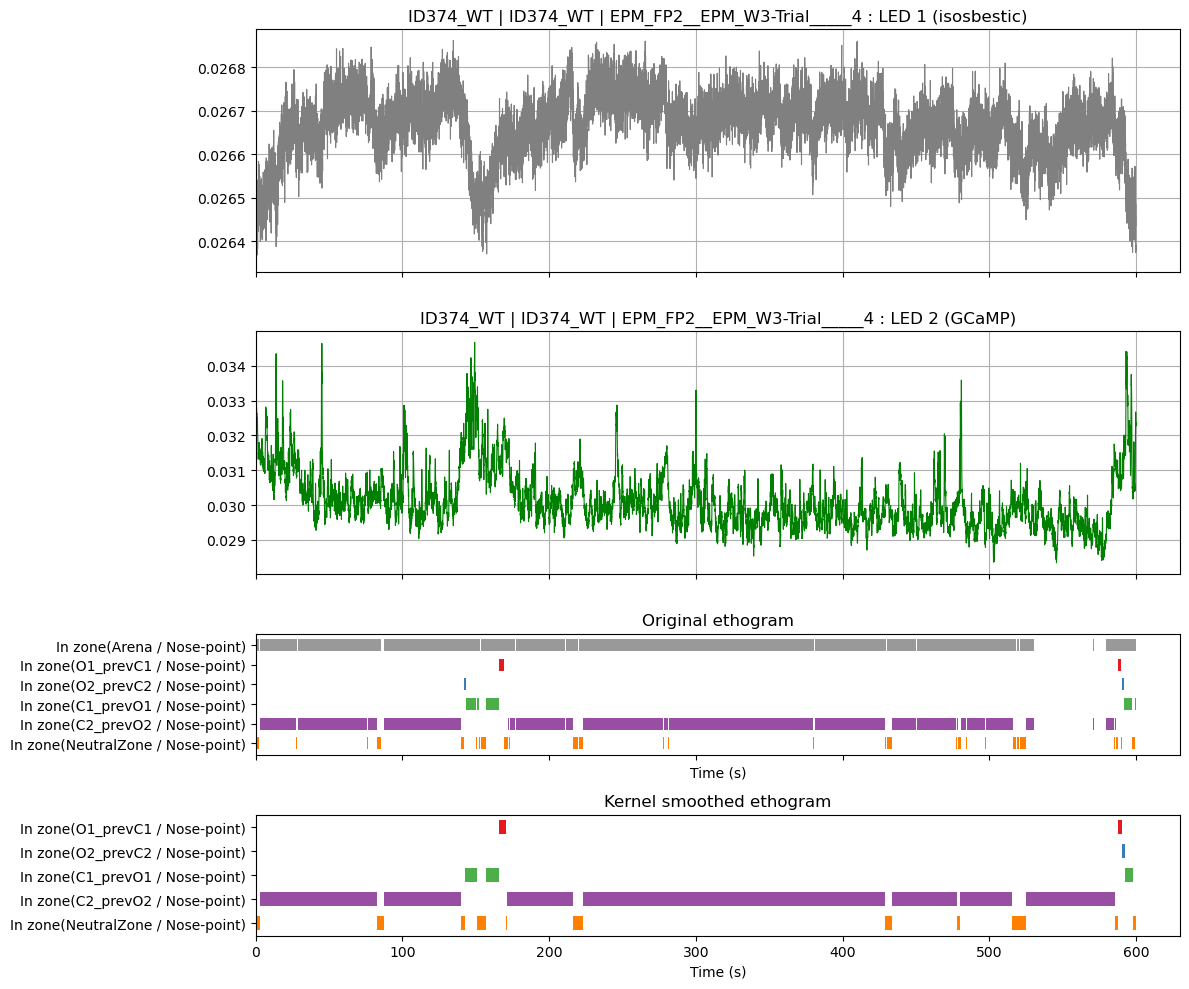

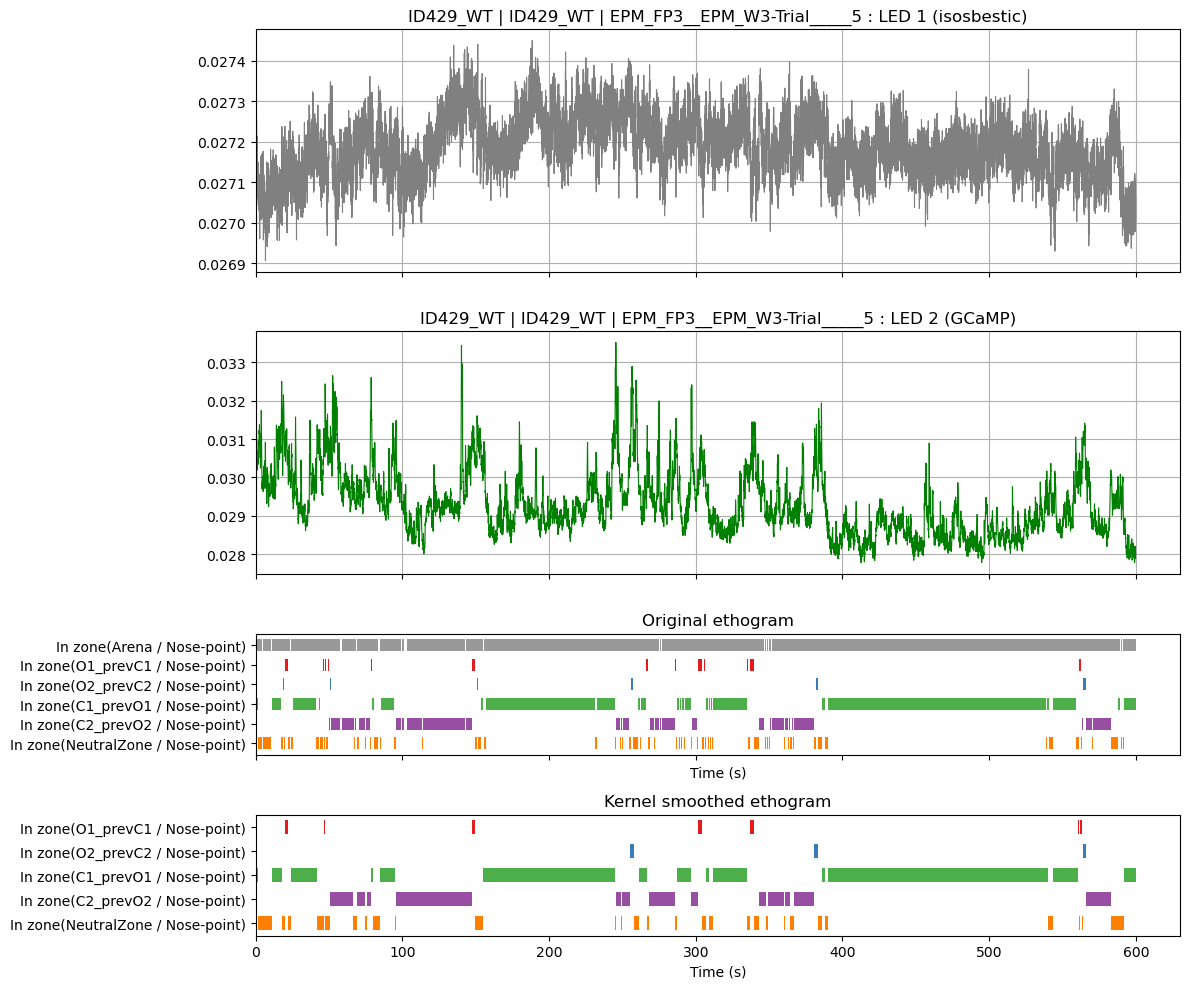

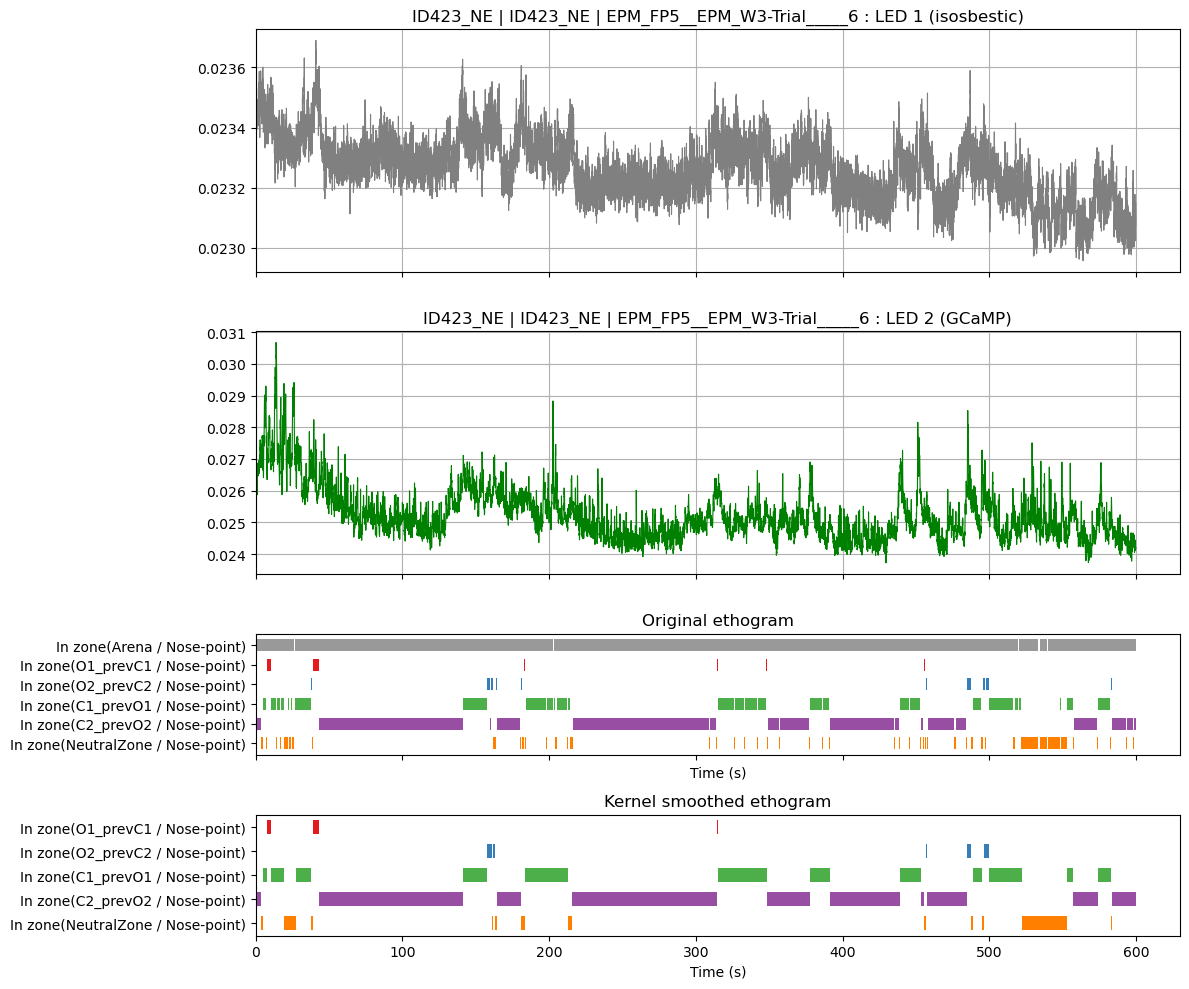

In [20]:
# ==========================================================
# Apply smoothing_kernel and plot kernel-smoothed ethograms for all trials
# ==========================================================

for trial_key, trial_data in fp_traces.items():
    try:
        # Extract FP traces and timeline
        iso_df = trial_data["iso"]
        gcamp_df = trial_data["gcamp"]
        timeline = trial_data["timeline"]
        mouse_label = f"ID{trial_data['mouse_id']}" + (f"_{trial_data['genotype']}" if trial_data['genotype'] else "")
        fp_id = trial_key.split("__")[1]
        trial_stub = "__".join(trial_key.split("__")[2:])

        # # Filter out arena zone before smoothing
        # timeline_filter = timeline[timeline['Behavior'] != 'In zone(Arena / Nose-point)'] \
        #                   .sort_values('Start_time_s')

        # # Apply your original smoothing kernel
        # timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
        # Filter out arena zone before smoothing
        timeline_filter = timeline[
            ~timeline['Behavior'].str.contains('Arena / Nose-point', case=False)
        ].sort_values('Start_time_s')

        # Apply your original smoothing kernel
        timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
        
        # Store kernel-smoothed timeline for later access
        trial_data["timeline_kernel"] = timeline_kernel_labels


        # Plot
        fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 2, 1, 1]})

        # --- FP traces ---
        iso_col = [c for c in iso_df.columns if c != "Time_video"][0]    # dynamically get numeric column
        gcamp_col = [c for c in gcamp_df.columns if c != "Time_video"][0]

        axes[0].plot(iso_df["Time_video"], iso_df[iso_col], linewidth=0.8, color="gray")
        axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
        axes[0].grid(True)

        axes[1].plot(gcamp_df["Time_video"], gcamp_df[gcamp_col], linewidth=0.8, color="green")
        axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
        axes[1].grid(True)

        # --- Original ethogram ---
        beh_cols_orig = trial_data["beh_cols"]
        for i, beh in enumerate(beh_cols_orig):
            color = _guess_zone_color(beh)
            subset = timeline[timeline["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[2].set_yticks(range(len(beh_cols_orig)))
        axes[2].set_yticklabels(beh_cols_orig)
        axes[2].invert_yaxis()
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Original ethogram")

        # --- Kernel-smoothed ethogram ---
        # beh_cols_clean = [
        #     'In zone(O1_prevC1 / Nose-point)',
        #     'In zone(O2_prevC2 / Nose-point)',
        #     'In zone(C1_prevO1 / Nose-point)',
        #     'In zone(C2_prevO2 / Nose-point)',
        #     'In zone(NeutralZone / Nose-point)'
        # ]
        # for i, beh in enumerate(beh_cols_clean):
        #     color = _guess_zone_color(beh)
        #     subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
        #     for _, row in subset.iterrows():
        #         axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        # axes[3].set_yticks(range(len(beh_cols_clean)))
        # axes[3].set_yticklabels(beh_cols_clean)
        # axes[3].invert_yaxis()
        # axes[3].set_xlabel("Time (s)")
        # axes[3].set_title("Kernel smoothed ethogram")



        # # --- Kernel-smoothed ethogram ---
        # beh_cols_clean = timeline_kernel_labels["Behavior"].unique()  # dynamically get labels
        # for i, beh in enumerate(beh_cols_clean):
        #     color = _guess_zone_color(beh)
        #     subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
        #     for _, row in subset.iterrows():
        #         axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        # axes[3].set_yticks(range(len(beh_cols_clean)))
        # axes[3].set_yticklabels(beh_cols_clean)
        # axes[3].invert_yaxis()
        # axes[3].set_xlabel("Time (s)")
        # axes[3].set_title("Kernel smoothed ethogram")
        # --- Kernel-smoothed ethogram ---
        beh_cols_clean = [b for b in beh_cols_orig if 'Arena / Nose-point' not in b]  # same order as original, arena removed
        for i, beh in enumerate(beh_cols_clean):
            color = _guess_zone_color(beh)
            subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[3].set_yticks(range(len(beh_cols_clean)))
        axes[3].set_yticklabels(beh_cols_clean)
        axes[3].invert_yaxis()
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Kernel smoothed ethogram")



        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[WARN] Could not plot trial {trial_key}: {e}")


In [21]:
for trial_key, trial_data in fp_traces.items():
    print(f"\nTrial: {trial_key}")
    if "timeline_kernel" not in trial_data:
        print("  No kernel-smoothed ethogram found.")
        continue

    tk = trial_data["timeline_kernel"]

    # Count number of separate occurrences for each behavior
    counts = tk["Behavior"].value_counts()
    for beh, n in counts.items():
        print(f"  {beh}: {n} instance(s)")



Trial: Preinduction__ID376_NE__EPM_FP0__EP_preinduction_BigArena-Trial_____1
  In zone 3(NeutralZone / Nose-point): 24 instance(s)
  In zone 3(C2_prevO2 / Nose-point): 10 instance(s)
  In zone 3(C1_prevO1 / Nose-point): 9 instance(s)
  In zone 3(O1_prevC1 / Nose-point): 6 instance(s)
  In zone 3(O2_prevC2 / Nose-point): 4 instance(s)

Trial: Preinduction__ID372_NE__EPM_FP1__EP_preinduction_BigArena-Trial_____2
  In zone 3(NeutralZone / Nose-point): 39 instance(s)
  In zone 3(O1_prevC1 / Nose-point): 13 instance(s)
  In zone 3(O2_prevC2 / Nose-point): 13 instance(s)
  In zone 3(C1_prevO1 / Nose-point): 10 instance(s)
  In zone 3(C2_prevO2 / Nose-point): 10 instance(s)

Trial: Preinduction__ID374_WT__EPM_FP2__EP_preinduction_BigArena-Trial_____3
  In zone 3(NeutralZone / Nose-point): 36 instance(s)
  In zone 3(C2_prevO2 / Nose-point): 19 instance(s)
  In zone 3(O2_prevC2 / Nose-point): 11 instance(s)
  In zone 3(O1_prevC1 / Nose-point): 9 instance(s)
  In zone 3(C1_prevO1 / Nose-point):

In [23]:
# Get the last trial key
last_key = list(fp_traces.keys())[-1]
trial_data = fp_traces[last_key]

print(f"Full kernel-smoothed timeline for trial: {last_key}\n")

if "timeline_kernel" in trial_data:
    tk = trial_data["timeline_kernel"]
    # Print all columns
    print(tk.to_string(index=False))
else:
    print("No kernel-smoothed ethogram found for this trial.")


Full kernel-smoothed timeline for trial: W3__ID423_NE__EPM_FP5__EPM_W3-Trial_____6

                         Behavior  Start_time_s  End_time_s  Duration_s
  In zone(C2_prevO2 / Nose-point)         0.000       3.821       3.821
In zone(NeutralZone / Nose-point)         3.821       4.621       0.800
  In zone(C1_prevO1 / Nose-point)         4.621       7.362       2.741
  In zone(O1_prevC1 / Nose-point)         7.362      10.323       2.961
  In zone(C1_prevO1 / Nose-point)        10.323      19.326       9.003
In zone(NeutralZone / Nose-point)        19.326      27.208       7.882
  In zone(C1_prevO1 / Nose-point)        27.208      37.711      10.503
In zone(NeutralZone / Nose-point)        37.711      38.971       1.260
  In zone(O1_prevC1 / Nose-point)        38.971      43.212       4.241
  In zone(C2_prevO2 / Nose-point)        43.212     141.281      98.069
  In zone(C1_prevO1 / Nose-point)       141.281     157.706      16.425
  In zone(O2_prevC2 / Nose-point)       157.706     

In [25]:
# Get the last trial key
last_key = list(fp_traces.keys())[-1]
trial_data = fp_traces[last_key]

print(f"Kernel-smoothed timeline for trial: {last_key} — O1 only\n")

if "timeline_kernel" in trial_data:
    tk = trial_data["timeline_kernel"]
    # Filter for O1 behavior
    tk_o1 = tk[tk["Behavior"] == "In zone(O2_prevC2 / Nose-point)"].sort_values("Start_time_s")
    if tk_o1.empty:
        print("No O1 entries found in this trial.")
    else:
        print(tk_o1.to_string(index=False))
else:
    print("No kernel-smoothed ethogram found for this trial.")


Kernel-smoothed timeline for trial: W3__ID423_NE__EPM_FP5__EPM_W3-Trial_____6 — O1 only

                       Behavior  Start_time_s  End_time_s  Duration_s
In zone(O2_prevC2 / Nose-point)       157.706     160.807       3.101
In zone(O2_prevC2 / Nose-point)       161.507     163.267       1.760
In zone(O2_prevC2 / Nose-point)       164.127     164.527       0.400
In zone(O2_prevC2 / Nose-point)       180.852     180.952       0.100
In zone(O2_prevC2 / Nose-point)       456.512     456.552       0.040
In zone(O2_prevC2 / Nose-point)       456.692     457.592       0.900
In zone(O2_prevC2 / Nose-point)       484.720     487.461       2.741
In zone(O2_prevC2 / Nose-point)       495.603     495.704       0.101
In zone(O2_prevC2 / Nose-point)       496.524     499.985       3.461


# code for manually subtracting iso from gcamp by aligning iso and gcamp to occur at same timepoints (a bit artificial, they do not occur at exactly the same timepoint)

In [ ]:
# ==========================================================
# Coregister ISO and GCaMP traces for all timepoints
# ==========================================================

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """
    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso[iso_col].values,
        "gcamp470": gcamp[gcamp_col].values,
    })

    return aligned

# -------------------------------------------------
# Apply coregistration to all trials in fp_traces
# -------------------------------------------------

coregistered_traces = {}  # store results per trial

for tp in timepoints:
    # Filter keys for this timepoint
    tp_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
    for k in tp_keys:
        try:
            aligned_df = coregister_iso_gcamp(fp_traces[k])
            coregistered_traces[k] = aligned_df
        except Exception as e:
            print(f"[WARN] Could not coregister {k}: {e}")

# Example access:


In [ ]:
# Show the first key
first_key = list(coregistered_traces.keys())[1]
print("First trial key:", first_key)

# Show the head of the aligned dataframe
print(coregistered_traces[first_key].head())


# apply zero-phase moving window - not using subtracted data

After extraction of the data, a zero-phase moving average linear digital filter is applied backwards and forwards to both the channels to reduce high frequency noise without time-shifting. The standard window for the moving filter is 100 data points i GuPPy, but can be adjusted by the user when setting input parameters. The window needs to be adjusted depending on the sampling rate of the recorded data. Guidelines are provided in the user guide. The traces resulting after this filtering step will be displayed for the user to inspect before proceeding with analysis.

In [ ]:
import numpy as np
from scipy.signal import filtfilt

def zero_phase_moving_average(signal, window_pts=5):
    """
    GuPPy-style zero-phase moving average.
    """
    signal = np.asarray(signal, dtype=float)

    if window_pts < 1:
        raise ValueError("window_pts must be >= 1")

    kernel = np.ones(window_pts, dtype=float) / window_pts

    filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
    return filtered


# ==========================================================
# Apply zero-phase moving average to all aligned trials
# ==========================================================

smoothed_trials = {}

window_pts = 5  # ≈ 4 seconds at 25 Hz alternation

for key, df in coregistered_traces.items():     # FIXED HERE
    try:
        smoothed_df = df.copy()
        smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
        smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
        smoothed_trials[key] = smoothed_df
    except Exception as e:
        print(f"[WARN] Could not smooth trial {key}: {e}")

# Example output
example_key = list(smoothed_trials.keys())[0]
print(f"Example smoothed trial: {example_key}")
print(smoothed_trials[example_key].head())


In [ ]:
# import numpy as np
# from scipy.signal import filtfilt

# def zero_phase_moving_average(signal, window_pts=5):
#     """
#     GuPPy-style zero-phase moving average.

#     signal: 1D array-like
#     window_pts: length of moving average window in samples.
#                 For your data (~25 Hz), 100 pts ≈ 4 seconds.
#     """
#     signal = np.asarray(signal, dtype=float)

#     if window_pts < 1:
#         raise ValueError("window_pts must be >= 1")

#     # Moving average kernel
#     kernel = np.ones(window_pts, dtype=float) / window_pts

#     # Zero-phase: forward + backward filtering
#     filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
#     return filtered

# # ==========================================================
# # Apply zero-phase moving average to all aligned trials
# # ==========================================================

# smoothed_trials = {}

# # window_pts can be adjusted per your data; default is 100
# window_pts = 100

# for key, df in aligned_trials.items():
#     try:
#         smoothed_df = df.copy()
#         smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
#         smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
#         smoothed_trials[key] = smoothed_df
#     except Exception as e:
#         print(f"[WARN] Could not smooth trial {key}: {e}")

# # Example: check one smoothed trial
# example_key = list(smoothed_trials.keys())[0]
# print(f"Example smoothed trial: {example_key}")
# print(smoothed_trials[example_key].head())


Nice, you found the key bit in their methods. That paragraph is describing what happens on the TDT rig, not in GuPPy itself:
465 nm and 405 nm LEDs … were demodulated using a 4 Hz low-pass frequency filter.
So there are actually two separate filtering stages in their setup:
Hardware / Synapse side (TDT)
LEDs modulated at ~200–330 Hz
Demodulated and low-pass filtered at 4 Hz on the RZ5P
This already strips out the fast carrier and most high-frequency noise
Software side (GuPPy)
GuPPy then adds a zero-phase moving average filter with a user-defined window (default 100 points) on the demodulated streams
The “Window for Moving Average filter” in GuPPy refers to step 2.
How to think about window_pts in terms of your sampling rate
​	
Larger M → lower cutoff → more aggressive smoothing
Smaller M → higher cutoff → lighter smoothing
What did GuPPy likely do in their own rig?
On TDT they say “demodulated using a 4 Hz low-pass filter”. If their demodulated stream was at around 1 kHz (typical for RZ5P), then:

​	
 ≈4.4 Hz
So a 100-point moving average at ~1 kHz naturally gives about a 4 Hz cutoff, which matches their description.
In your case, though, you’re working with already demultiplexed / downsampled FP3002-style traces at ~25 Hz per channel.
What is “appropriate” for 25 Hz per channel?

​	
 
Some example window_pts:
M (window_pts)	f_c (approx)	Smoothed time scale
3	~3.7 Hz	very light smoothing, almost raw
5	~2.2 Hz	light smoothing
11	~1.0 Hz	moderate smoothing over ~1 s
25	~0.44 Hz	strong smoothing over several seconds
75	~0.15 Hz	very slow trend only, kills fast dynamics

Start with window_pts = 5–11
5 points → f_c ≈ 2.2 Hz (light smoothing)
11 points → f_c ≈ 1.0 Hz (moderate smoothing)

In [ ]:
# # ==========================================================
# # Apply zero-phase moving average to all coregistered trials
# # ==========================================================

# smoothed_trials = {}

# # window_pts can be adjusted per your data; default is 100
# window_pts = 5

# for key, df in coregistered_traces.items():   # <-- use coregistered_traces
#     try:
#         smoothed_df = df.copy()
#         smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
#         smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
#         smoothed_trials[key] = smoothed_df
#     except Exception as e:
#         print(f"[WARN] Could not smooth trial {key}: {e}")

# # Example: check one smoothed trial
# example_key = list(smoothed_trials.keys())[0]
# print(f"Example smoothed trial: {example_key}")
# print(smoothed_trials[example_key].head())


If you want to process ISO and GCaMP separately (without merging/alignment), you can compute filtered traces only or optionally z-score each independently. ∆F/F won’t make sense without alignment, but you can still smooth and analyze each channel.

In [ ]:
# import numpy as np

# dFF_trials = {}

# for key, df in smoothed_trials.items():  # <-- use smoothed_trials
#     df = df.copy()

#     # 1) Take filtered iso (control) and gcamp (signal) traces as numpy arrays
#     x = df["iso415_smooth"].to_numpy()   # control (405)
#     y = df["gcamp470_smooth"].to_numpy() # signal (470)

#     # 2) Mask out NaNs or infs
#     mask = np.isfinite(x) & np.isfinite(y)
#     x_fit = x[mask]
#     y_fit = y[mask]

#     # 3) Least squares linear regression: y ≈ a*x + b
#     if len(x_fit) < 2:
#         print(f"[WARN] Not enough valid points to fit trial {key}")
#         continue
#     a, b = np.polyfit(x_fit, y_fit, 1)

#     # 4) Fitted control trace for all points
#     Y_fit_all = a * x + b

#     # 5) Delta F = signal − fitted control
#     Y_dF_all = y - Y_fit_all

#     # 6) ∆F/F (%) = 100 * (ΔF / fitted control)
#     eps = np.finfo(float).eps  # avoid division by zero
#     dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

#     # 7) Store results in DataFrame
#     df["iso_fit"] = Y_fit_all       # fitted baseline
#     df["dFF"]     = dFF             # ∆F/F in percent

#     # 8) Optional: z-score the dF/F
#     mu  = np.nanmean(dFF)
#     sig = np.nanstd(dFF)
#     df["dFF_z"] = (dFF - mu) / sig if sig > 0 else np.zeros_like(dFF)

#     # Update trial in dictionary
#     dFF_trials[key] = df

# # Example: inspect one trial
# example_key = list(dFF_trials.keys())[0]
# print(f"Example dF/F processed trial: {example_key}")
# print(dFF_trials[example_key].head())


what you’re plotting is not the regression line in 2D space, but the 405 time-series passed through the regression model.

In [ ]:
import numpy as np

preproc_trials = {}

for key, df in smoothed_trials.items():
    df = df.copy()

    # Take smoothed iso (control) and gcamp (signal)
    x = df["iso415_smooth"].to_numpy()
    y = df["gcamp470_smooth"].to_numpy()

    # Mask invalid values
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 2:
        print(f"[WARN] Not enough valid points for trial {key}")
        continue

    # Linear regression: y ≈ a*x + b
    a, b = np.polyfit(x_fit, y_fit, 1)

    # Fitted baseline
    Y_fit_all = a * x + b

    # Delta F
    Y_dF_all = y - Y_fit_all

    # ∆F/F (%)
    eps = np.finfo(float).eps
    dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

    # z-scored ∆F/F
    mu  = np.nanmean(dFF)
    sig = np.nanstd(dFF)
    dFF_z = (dFF - mu)/sig if sig > 0 else np.zeros_like(dFF)

    # Store in DataFrame
    df["iso_fit"] = Y_fit_all
    df["dFF"] = dFF
    df["dFF_z"] = dFF_z

    preproc_trials[key] = df


In [ ]:
import matplotlib.pyplot as plt

def plot_preproc_trial(df, key, save_dir=None):
    """
    Plot:
        1) ISO smoothed
        2) GCaMP smoothed
        3) Fitted baseline
        4) dF/F (%)

    df must contain:
        Time_video
        iso415_smooth
        gcamp470_smooth
        iso_fit
        dFF
    """
    time = df["Time_video"].values

    iso  = df["iso415_smooth"].values
    gcamp = df["gcamp470_smooth"].values
    baseline = df["iso_fit"].values
    dFF = df["dFF"].values

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    # 1) ISO 415
    axes[0].plot(time, iso, color="gray", linewidth=1)
    axes[0].set_title(f"{key} — ISO 415 smoothed")
    axes[0].set_ylabel("Signal")

    # 2) GCaMP 470
    axes[1].plot(time, gcamp, color="green", linewidth=1)
    axes[1].set_title("GCaMP 470 smoothed")
    axes[1].set_ylabel("Signal")

    # 3) Baseline fit vs GCaMP
    axes[2].plot(time, gcamp, color="green", linewidth=0.8, label="GCaMP")
    axes[2].plot(time, baseline, color="black", linewidth=0.8, linestyle="--",
                 label="Fitted baseline")
    axes[2].set_title("GCaMP with fitted baseline")
    axes[2].legend(loc="upper right")
    axes[2].set_ylabel("Value")

    # 4) dF/F
    axes[3].plot(time, dFF, color="purple", linewidth=0.8)
    axes[3].set_title("dF/F (%)")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("%")

    plt.tight_layout()

    # Save or show
    if save_dir is not None:
        out = save_dir / f"{key}_preproc.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:
# Plot preprocessed trials with fitted baseline and dF/F
for key in preproc_trials.keys():  # <-- use preproc_trials, not smoothed_trials
    try:
        plot_preproc_trial(preproc_trials[key], key)
    except Exception as e:
        print(f"[WARN] Could not plot {key}: {e}")


# Putting together corrections to ethovision ethogram and FP preprocessed traces

below code uses all the preprocessed signals, also the intermediares + skip to the next block to see only delta F over F signal

In [ ]:
def map_behavior_to_time(time_vector, timeline_kernel):
    """
    Map the kernel-smoothed behavior to each timepoint in the FP time vector.
    
    Args:
        time_vector (np.array): FP time points (Time_video)
        timeline_kernel (pd.DataFrame): Kernel-smoothed ethogram with columns
                                        ['Behavior', 'Start_time_s', 'End_time_s']
    Returns:
        np.array: Behavior label for each time point
    """
    behavior_at_time = np.array(["Unknown"] * len(time_vector), dtype=object)

    for _, row in timeline_kernel.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]

    return behavior_at_time


In [ ]:
combined_trials = {}

for key in preproc_trials.keys():
    df = preproc_trials[key].copy()
    if "timeline_kernel" in fp_traces[key]:
        timeline_kernel = fp_traces[key]["timeline_kernel"]
        df["Behavior"] = map_behavior_to_time(df["Time_video"].values, timeline_kernel)
    else:
        df["Behavior"] = "Unknown"  # fallback
    combined_trials[key] = df


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_fp_with_ethogram(df, key, save_dir=None):
    """
    Plot FP preprocessed traces together with kernel-smoothed ethogram.
    
    df must contain:
        Time_video
        iso415_smooth
        gcamp470_smooth
        iso_fit
        dFF
        Behavior
    """
    time = df["Time_video"].values
    iso = df["iso415_smooth"].values
    gcamp = df["gcamp470_smooth"].values
    baseline = df["iso_fit"].values
    dFF = df["dFF"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1, 1]})

    # --- 1) ISO 415 ---
    axes[0].plot(time, iso, color="gray", linewidth=1)
    axes[0].set_ylabel("ISO 415")
    axes[0].set_title(f"{key} — FP + Kernel-smoothed ethogram")

    # --- 2) GCaMP 470 ---
    axes[1].plot(time, gcamp, color="green", linewidth=1)
    axes[1].set_ylabel("GCaMP 470")

    # --- 3) Baseline vs GCaMP ---
    axes[2].plot(time, gcamp, color="green", linewidth=0.8, label="GCaMP")
    axes[2].plot(time, baseline, color="black", linewidth=0.8, linestyle="--", label="Fitted baseline")
    axes[2].set_ylabel("Value")
    axes[2].legend(loc="upper right")

    # --- 4) dF/F (%) ---
    axes[3].plot(time, dFF, color="purple", linewidth=0.8)
    axes[3].set_ylabel("dF/F (%)")
    axes[3].set_xlabel("Time (s)")

    # --- Overlay ethogram as colored bands ---
    for ax in axes:
        for beh in beh_labels:
            mask = behaviors == beh
            ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                            where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Create legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    axes[0].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    # Save or show
    if save_dir is not None:
        out = save_dir / f"{key}_FP_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:
example_key = list(combined_trials.keys())[0]
plot_fp_with_ethogram(combined_trials[example_key], example_key)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_dff_with_ethogram(df, key, save_dir=None):
    """
    Plot only the dF/F (%) signal together with kernel-smoothed ethogram.

    df must contain:
        Time_video
        dFF
        Behavior
    """
    time = df["Time_video"].values
    dFF = df["dFF"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))

    # Plot dF/F
    ax.plot(time, dFF, color="purple", linewidth=1)
    ax.set_ylabel("dF/F (%)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — dF/F with kernel-smoothed ethogram")

    # Overlay ethogram as colored bands
    for beh in beh_labels:
        mask = behaviors == beh
        ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    if save_dir is not None:
        out = save_dir / f"{key}_dFF_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:
example_key = list(combined_trials.keys())[1]
plot_dff_with_ethogram(combined_trials[example_key], example_key)


# PERI EVENT PLOTS CORRECTED SIGNAL


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0      # seconds before event
post_s = 4.0     # seconds after event
min_stay_s = 0   # optional, if you want to filter very short events

# Pick first trial
example_key = list(combined_trials.keys())[1]
df = combined_trials[example_key].copy()

time_vec = df["Time_video"].values
signal_vec = df["dFF"].values
behaviors = df["Behavior"].values

# Unique behaviors
unique_beh = np.unique(behaviors)

# Loop over behaviors
for beh in unique_beh:
    # Find event starts (transition into this behavior)
    mask = (behaviors == beh)
    mask_int = mask.astype(int)  # convert bool to int
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # rising edges

    # Skip if no events
    if len(event_starts_idx) == 0:
        print(f"No events found for {beh}")
        continue

    # Convert pre/post window to samples
    fps = 1 / np.mean(np.diff(time_vec))  # effective sampling rate
    pre_n = int(pre_s * fps)
    post_n = int(post_s * fps)

    # Collect peri-event segments
    segments = []
    for idx in event_starts_idx:
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            seg = signal_vec[idx-pre_n : idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Pick the trial
example_key = list(combined_trials.keys())[1]
df = combined_trials[example_key]

behaviors = df["Behavior"].values
unique_beh = np.unique(behaviors)

# Count number of instances (rising edges into each behavior)
event_counts = {}

for beh in unique_beh:
    mask = (behaviors == beh)
    mask_int = mask.astype(int)
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # transitions into behavior
    event_counts[beh] = len(event_starts_idx)

# Convert to DataFrame for display
event_counts_df = pd.DataFrame.from_dict(event_counts, orient="index", columns=["Num_Instances"])
event_counts_df.index.name = "Behavior"
event_counts_df


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0   # seconds before event
post_s = 4.0  # seconds after event

# Pick first trial
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()
timeline_kernel = fp_traces[example_key]["timeline_kernel"]

signal_vec = df["dFF"].values
time_vec = df["Time_video"].values

# Loop over behaviors using the ethogram segments
for beh in timeline_kernel["Behavior"].unique():
    segments = []

    # Find all start-end intervals for this behavior
    intervals = timeline_kernel[timeline_kernel["Behavior"] == beh]

    for _, row in intervals.iterrows():
        # Find closest index in the FP time vector
        start_idx = np.searchsorted(time_vec, row["Start_time_s"])
        end_idx   = np.searchsorted(time_vec, row["End_time_s"])

        # Peri-event window: pre_s before start, post_s after start
        fps = 1 / np.mean(np.diff(time_vec))
        pre_n = int(pre_s * fps)
        post_n = int(post_s * fps)
        if start_idx >= pre_n and (start_idx + post_n) < len(signal_vec):
            seg = signal_vec[start_idx-pre_n : start_idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [ ]:
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()

if "timeline_kernel" in fp_traces[example_key]:
    timeline_kernel = fp_traces[example_key]["timeline_kernel"]
else:
    raise ValueError(f"timeline_kernel not found for trial {example_key}")
